In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import torch
import os
import glob

In [4]:
TASKS = ['pickblueblock', 'uprightcup', 'putgreeninpot']
MAX_OUTCOME = {'pickblueblock': 2.0, 'uprightcup': 3.0, 'putgreeninpot': 6.0}
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
})

### Analyze ground truth results
- compositional generalization: in-distribution vs. OOD outcomes

In [ ]:
def print_stats(name, df):
    print(f"{name}:")
    if df.empty:
        print("No data points found for this condition.\n")
        return
    
    continuous_outcome = df['continuous_outcome'].describe()
    binary_success_rate = (df['binary_outcome'] == 1).mean() * 100
    
    # print(f"Count: {int(stats['count'])}")
    print(f"Mean Outcome (continuous): {continuous_outcome['mean']:.4f}")
    # print(f"Success Rate (binary): {success_rate:.2f}%")
    
    return continuous_outcome, binary_success_rate

def print_id_ood_stats(bf_data):
    # In-distribution filters
    # 1. Define the ID filters
    # Condition 1: Bottom left and Top right quadrants
    quadrant_mask = (
        ((bf_data['x'] <= 0.5) & (bf_data['y'] <= 0.5)) | 
        ((bf_data['x'] >= 0.5) & (bf_data['y'] >= 0.5))
    )

    # Condition 2: Specific camera viewpoint (azimuth = 15)
    camera_mask = (bf_data['camera_azimuth'] == -30) | (bf_data['camera_azimuth'] == 90)

    # Condition 3: Table height = 2
    height_mask = (bf_data['table_height'] == 1) | (bf_data['table_height'] == 3)

    # 2. Extract the subsets
    id_quadrants = bf_data[quadrant_mask]
    id_azimuth = bf_data[camera_mask]
    id_height = bf_data[height_mask]

    # 3. Print analysis summary
    print(f"IN-DISTRIBUTION")
    print_stats("Table Quadrants: Top-Right, Bottom-Left", id_quadrants)
    print_stats("Camera Viewpoint: Back, Right", id_azimuth)
    print_stats("Table Height: 1, 3", id_height)

    print("\n")

    # OOD filters
    quadrant_mask = (
        ((bf_data['x'] >= 0.5) & (bf_data['y'] <= 0.5)) | 
        ((bf_data['x'] <= 0.5) & (bf_data['y'] >= 0.5))
    )
    camera_mask = (bf_data['camera_azimuth'] == 15)
    height_mask = (bf_data['table_height'] == 2)

    ood_quadrants = bf_data[quadrant_mask]
    ood_azimuth = bf_data[camera_mask]
    ood_height = bf_data[height_mask]

    print(f"OUT-OF-DISTRIBUTION")
    print_stats("Table Quadrants: Top-Left, Bottom-Right", ood_quadrants)
    print(f"Difference: {round((ood_quadrants['continuous_outcome'].mean() - id_quadrants['continuous_outcome'].mean()) / id_quadrants['continuous_outcome'].mean() * 100, 1)}%")
    print_stats("Camera Viewpoint: Back-Right", ood_azimuth)
    print(f"Difference: {round((ood_azimuth['continuous_outcome'].mean() - id_azimuth['continuous_outcome'].mean()) / id_azimuth['continuous_outcome'].mean() * 100, 1)}%")
    print_stats("Table Height: 2", ood_height)
    print(f"Difference: {round((ood_height['continuous_outcome'].mean() - id_height['continuous_outcome'].mean()) / id_height['continuous_outcome'].mean() * 100, 1)}%")


def plot_id_ood_comparison(bf_data, task_name):
    """
    Creates a grouped bar chart comparing ID and OOD mean outcomes 
    for each factor and saves it as an image.
    """
    categories = ['Quadrant', 'Camera', 'Height']
    
    # Define masks as used in print_id_ood_stats
    masks = {
        'Quadrant': {
            'ID': ((bf_data['x'] <= 0.5) & (bf_data['y'] <= 0.5)) | ((bf_data['x'] >= 0.5) & (bf_data['y'] >= 0.5)),
            'OOD': ((bf_data['x'] >= 0.5) & (bf_data['y'] <= 0.5)) | ((bf_data['x'] <= 0.5) & (bf_data['y'] >= 0.5))
        },
        'Camera': {
            'ID': (bf_data['camera_azimuth'] == -30) | (bf_data['camera_azimuth'] == 90),
            'OOD': (bf_data['camera_azimuth'] == 15)
        },
        'Height': {
            'ID': (bf_data['table_height'] == 1) | (bf_data['table_height'] == 3),
            'OOD': (bf_data['table_height'] == 2)
        }
    }

    id_means = []
    ood_means = []
    diffs = []

    for cat in categories:
        m_id = bf_data[masks[cat]['ID']]['continuous_outcome'].mean()
        m_ood = bf_data[masks[cat]['OOD']]['continuous_outcome'].mean()
        
        id_means.append(m_id)
        ood_means.append(m_ood)
        
        # Calculate % difference for the label
        if m_id != 0:
            perc_diff = ((m_ood - m_id) / m_id) * 100
        else:
            perc_diff = 0
        diffs.append(perc_diff)

    # Plotting
    x = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, id_means, width, label='In-Distribution (ID)', color='lightgray', edgecolor='black', alpha=0.8)
    rects2 = ax.bar(x + width/2, ood_means, width, label='Out-of-Distribution (OOD)', color='#3b4cc0', edgecolor='black', alpha=0.8)

    # Add labels, title and custom x-axis tick labels
    ax.set_ylabel('Mean Continuous Outcome', fontsize=12)
    ax.set_title(f'ID vs. OOD Performance Comparison: {task_name} (Max Outcome: {MAX_OUTCOME[task_name]})', fontsize=14, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()

    # Add percentage labels on top of the OOD bars
    for i, rect in enumerate(rects2):
        height = rect.get_height()
        ax.annotate(f'{diffs[i]:+.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    save_path = f"./visualizations/robo_eval/generalization/{task_name}_id_vs_ood_comparison.png"
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"Saved comparison chart to {save_path}")

In [3]:
for task in TASKS:
    print(f"---   TASK: {task}   ---")
    bf_data = pd.read_csv(f'./results/{task}_bruteforce/results.csv')
    print(f"Loaded ground truth data: {len(bf_data)} points")
    print(f"Maximum outcome (success) value: {MAX_OUTCOME[task]}")
    print("\n")
    
    print_id_ood_stats(bf_data)
    plot_id_ood_comparison(bf_data, task)
    
    print("\n")

---   TASK: pickblueblock   ---
Loaded ground truth data: 804 points
Maximum outcome (success) value: 2.0


IN-DISTRIBUTION
Table Quadrants: Top-Right, Bottom-Left:
Mean Outcome (continuous): 1.4733
Camera Viewpoint: Back, Right:
Mean Outcome (continuous): 1.2201
Table Height: 1, 3:
Mean Outcome (continuous): 1.1359


OUT-OF-DISTRIBUTION
Table Quadrants: Top-Left, Bottom-Right:
Mean Outcome (continuous): 0.7623
Difference: -48.3%
Camera Viewpoint: Back-Right:
Mean Outcome (continuous): 0.9664
Difference: -20.8%
Table Height: 2:
Mean Outcome (continuous): 1.1348
Difference: -0.1%
Saved comparison chart to ./visualizations/robo_eval/generalization/pickblueblock_id_vs_ood_comparison.png


---   TASK: uprightcup   ---
Loaded ground truth data: 804 points
Maximum outcome (success) value: 3.0


IN-DISTRIBUTION
Table Quadrants: Top-Right, Bottom-Left:
Mean Outcome (continuous): 1.6480
Camera Viewpoint: Back, Right:
Mean Outcome (continuous): 1.3731
Table Height: 1, 3:
Mean Outcome (continuous

In [ ]:
# 1-2 factor combinations
def plot_ood_compositional_heatmap(bf_data, task_name, model=None, factor_columns=None, tkwargs=None):
    """
    Generates a lower-triangular heatmap showing outcome changes 
    when single or multiple factors are OOD.
    
    Args:
        bf_data: DataFrame containing the data.
        task_name: Name of the task for titling and saving.
        model: Trained BoTorch model (optional). If provided, plots predictions.
        factor_columns: List of columns to use as inputs for the model (required if model is not None).
        tkwargs: Tensor kwargs dict, e.g., {'dtype': torch.double, 'device': 'cpu'} (optional).
    """
    factors = ['Quadrant', 'Camera', 'Height']
    
    # Define ID and OOD masks based on test.py logic
    masks_ood = {
        'Quadrant': ((bf_data['x'] >= 0.5) & (bf_data['y'] <= 0.5)) | ((bf_data['x'] <= 0.5) & (bf_data['y'] >= 0.5)),
        'Camera': (bf_data['camera_azimuth'] == 15),
        'Height': (bf_data['table_height'] == 2)
    }
    
    masks_id = {
        'Quadrant': ((bf_data['x'] <= 0.5) & (bf_data['y'] <= 0.5)) | ((bf_data['x'] >= 0.5) & (bf_data['y'] >= 0.5)),
        'Camera': (bf_data['camera_azimuth'] == -30) | (bf_data['camera_azimuth'] == 90),
        'Height': (bf_data['table_height'] == 1) | (bf_data['table_height'] == 3)
    }
    
    # --- NEW LOGIC: Setup target column based on model presence ---
    df_eval = bf_data.copy()
    target_col = 'eval_outcome'
    
    if model is not None:
        if factor_columns is None:
            raise ValueError("factor_columns must be provided to generate model predictions.")
        if tkwargs is None:
            tkwargs = {'dtype': torch.float64, 'device': 'cpu'} # Sensible default
            
        print("Generating model predictions for heatmap...")
        X_pred = torch.tensor(df_eval[factor_columns].values, **tkwargs)
        
        with torch.no_grad():
            posterior = model.posterior(X_pred)
            pred_mean = posterior.mean.squeeze(-1)
            # Handle Bayesian models with multiple samples
            if pred_mean.ndim == 2:
                pred_mean = pred_mean.mean(dim=0)
                
        df_eval[target_col] = pred_mean.cpu().numpy()
        title_prefix = "Predicted"
        save_suffix = "predicted"
    else:
        df_eval[target_col] = df_eval['continuous_outcome']
        title_prefix = "Ground Truth"
        save_suffix = "ground_truth"
    # --------------------------------------------------------------

    n = len(factors)
    diff_matrix = np.zeros((n, n))
    annot_matrix = np.empty((n, n), dtype=object)
    
    for i, row_f in enumerate(factors):
        for j, col_f in enumerate(factors):
            # Diagonal: Single factor OOD effect
            if i == j:
                base_mask = masks_id[row_f]
                ood_mask = masks_ood[row_f]
            # Off-diagonal: Combined (compositional) OOD effect
            else:
                base_mask = masks_id[row_f] & masks_id[col_f]
                ood_mask = masks_ood[row_f] & masks_ood[col_f]
                
            # Extract subsets and calculate values using the dynamic target column
            base_subset = df_eval[base_mask]
            ood_subset = df_eval[ood_mask]            
            base_mean = base_subset[target_col].mean()
            ood_mean = ood_subset[target_col].mean()
            count = len(ood_subset)
            
            # Calculate % difference relative to the ID baseline
            if base_mean and not np.isnan(base_mean):
                diff = ((ood_mean - base_mean) / base_mean) * 100
                diff_matrix[i, j] = diff
                annot_matrix[i, j] = f"{diff:+.1f}%\n({ood_mean:.2f})\n$n$={count}"
            else:
                diff_matrix[i, j] = np.nan
                annot_matrix[i, j] = "N/A"

    # Create the mask for the upper triangle to show only the "bottom diagonal"
    mask = np.triu(np.ones_like(diff_matrix, dtype=bool), k=1)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        diff_matrix, 
        mask=mask, 
        annot=annot_matrix, 
        fmt="", 
        cmap="coolwarm", 
        center=0,
        xticklabels=factors, 
        yticklabels=factors,
        square=True,
        cbar_kws={'label': 'Outcome Change (%)'},
        annot_kws={'fontweight': 'bold'}
    )
    
    # Use dynamic title and save paths
    # Assuming MAX_OUTCOME is in your global scope, otherwise you may want to pass it in.
    plt.title(f"{title_prefix} Compositional OOD Outcome: {task_name} (Max Outcome: {MAX_OUTCOME[task_name]})", pad=20)
    plt.tight_layout()
    plt.savefig(f"./visualizations/robo_eval/compositional_generalization/{task_name}_ood_heatmap_{save_suffix}.png")
    plt.show()

for task in TASKS:
    bf_data = pd.read_csv(f'./results/{task}_bruteforce/results.csv')
    active_model_path = f'./results/{task}_active_offline_SingleTaskGP_PSD/run_1/models/trial_50_model.pkl'

    with open(active_model_path, 'rb') as f:
        active_model_data = pickle.load(f)
        active_model = active_model_data['model']
    plot_ood_compositional_heatmap(bf_data, task, active_model, factor_columns=['x', 'y', 'table_height', 'camera_azimuth', 'camera_elevation', 'camera_distance'], tkwargs={'dtype': torch.float64, 'device': 'cpu'} )

In [ ]:
def get_model_predictions_across_runs(bf_data, model_base_dir, trial_k, factor_columns, tkwargs):
    """
    Finds all run_n folders in the base directory, loads trial_k_model.pkl,
    and returns an array of predictions of shape (num_runs, num_samples).
    """
    run_dirs = glob.glob(os.path.join(model_base_dir, "run_*"))
    all_preds = []
    
    if not run_dirs:
        print(f"Warning: No run directories found in {model_base_dir}")
        return np.array([])

    X_pred = torch.tensor(bf_data[factor_columns].values, **tkwargs)
    
    for run_dir in run_dirs:
        model_path = os.path.join(run_dir, "models", f"trial_{trial_k}_model.pkl")
        if not os.path.exists(model_path):
            print(f"Missing model: {model_path}")
            continue
            
        with open(model_path, 'rb') as f:
            model_data = pickle.load(f)
            model = model_data['model']
            
        with torch.no_grad():
            posterior = model.posterior(X_pred)
            pred_mean = posterior.mean.squeeze(-1)
            if pred_mean.ndim == 2:
                pred_mean = pred_mean.mean(dim=0)
        
        all_preds.append(pred_mean.cpu().numpy())
        
    return np.array(all_preds)


def plot_combined_id_ood_performance_multi_run(
    bf_data, task_name, model_base_dir, trial_k, factor_columns, tkwargs=None, max_outcome=None
):
    """
    Creates a grouped bar chart comparing GT and a Model across ID/OOD conditions.
    Bars represent the mean across runs, with error bars showing the standard deviation.
    """
    if tkwargs is None:
        tkwargs = {'dtype': torch.float64, 'device': 'cpu'}
        
    print(f"Generating model predictions across runs for trial {trial_k}...")
    model_preds = get_model_predictions_across_runs(bf_data, model_base_dir, trial_k, factor_columns, tkwargs)
    
    df_eval = bf_data.copy()

    # Define base ID and OOD masks
    masks_id = {
        'Quadrant': ((df_eval['x'] <= 0.5) & (df_eval['y'] <= 0.5)) | ((df_eval['x'] >= 0.5) & (df_eval['y'] >= 0.5)),
        'Camera': (df_eval['camera_azimuth'] == -30) | (df_eval['camera_azimuth'] == 90),
        'Height': (df_eval['table_height'] == 1) | (df_eval['table_height'] == 3)
    }
    
    masks_ood = {
        'Quadrant': ((df_eval['x'] >= 0.5) & (df_eval['y'] <= 0.5)) | ((df_eval['x'] <= 0.5) & (df_eval['y'] >= 0.5)),
        'Camera': (df_eval['camera_azimuth'] == 15),
        'Height': (df_eval['table_height'] == 2)
    }

    categories = [
        'Quadrant', 'Camera', 'Height', 'Quadrant + Camera', 
        'Camera + Height', 'Quadrant + Height', 'Quadrant + Camera + Height'
    ]

    cat_masks = {
        'Quadrant': {'ID': masks_id['Quadrant'], 'OOD': masks_ood['Quadrant']},
        'Camera': {'ID': masks_id['Camera'], 'OOD': masks_ood['Camera']},
        'Height': {'ID': masks_id['Height'], 'OOD': masks_ood['Height']},
        'Quadrant + Camera': {'ID': masks_id['Quadrant'] & masks_id['Camera'], 'OOD': masks_ood['Quadrant'] & masks_ood['Camera']},
        'Camera + Height': {'ID': masks_id['Camera'] & masks_id['Height'], 'OOD': masks_ood['Camera'] & masks_ood['Height']},
        'Quadrant + Height': {'ID': masks_id['Quadrant'] & masks_id['Height'], 'OOD': masks_ood['Quadrant'] & masks_ood['Height']},
        'Quadrant + Camera + Height': {'ID': masks_id['Quadrant'] & masks_id['Camera'] & masks_id['Height'], 'OOD': masks_ood['Quadrant'] & masks_ood['Camera'] & masks_ood['Height']}
    }

    # Data structures to hold means and standard deviations
    plot_data = {
        'GT': {'ID_mean': [], 'OOD_mean': []}, 
        'Model': {'ID_mean': [], 'ID_std': [], 'OOD_mean': [], 'OOD_std': []}
    }

    # Calculate combination categories
    for cat in categories:
        m_id, m_ood = cat_masks[cat]['ID'], cat_masks[cat]['OOD']
        
        # Ground Truth
        plot_data['GT']['ID_mean'].append(df_eval[m_id]['continuous_outcome'].mean())
        plot_data['GT']['OOD_mean'].append(df_eval[m_ood]['continuous_outcome'].mean())
        
        # Model (calculate mean for each run, then mean/std across those runs)
        if len(model_preds) > 0:
            run_id_means = model_preds[:, m_id].mean(axis=1)
            run_ood_means = model_preds[:, m_ood].mean(axis=1)
            
            plot_data['Model']['ID_mean'].append(run_id_means.mean())
            plot_data['Model']['ID_std'].append(run_id_means.std())
            plot_data['Model']['OOD_mean'].append(run_ood_means.mean())
            plot_data['Model']['OOD_std'].append(run_ood_means.std())
        else:
            plot_data['Model']['ID_mean'].append(0); plot_data['Model']['ID_std'].append(0)
            plot_data['Model']['OOD_mean'].append(0); plot_data['Model']['OOD_std'].append(0)

    # Calculate Overall means
    overall_gt = df_eval['continuous_outcome'].mean()
    # print(overall_gt)
    overall_model_mean = model_preds.mean(axis=1).mean() if len(model_preds) > 0 else 0
    overall_model_std = model_preds.mean(axis=1).std() if len(model_preds) > 0 else 0

    # --- Plotting ---
    width = 0.2
    fig, ax = plt.subplots(figsize=(7, 3.75))
    cap = 3 # Error bar cap size
    
    # 1. Plot 'Overall' at x=0 (2 bars)
    ax.bar(0 - width/2, overall_gt, width, label='GT Overall', color='#808080', edgecolor='black', alpha=0.9)
    ax.bar(0 + width/2, overall_model_mean, width, yerr=overall_model_std, capsize=cap, label='Model Overall', color='#5c6bc0', edgecolor='black', alpha=0.9)

    # 2. Plot the 4-bar clusters for the rest at x=1 to 7
    x = np.arange(1, len(categories) + 1)
    
    # Ground Truth Bars
    ax.bar(x - 1.5*width, plot_data['GT']['ID_mean'], width, label='GT ID', color='lightgray', edgecolor='black', alpha=0.9)
    rects_gt_ood = ax.bar(x - 0.5*width, plot_data['GT']['OOD_mean'], width, label='GT OOD', color='darkgray', edgecolor='black', alpha=0.9)
    
    # Model Bars
    ax.bar(x + 0.5*width, plot_data['Model']['ID_mean'], width, yerr=plot_data['Model']['ID_std'], capsize=cap, label='Model ID', color='#8fb0f0', edgecolor='black', alpha=0.9)
    rects_model_ood = ax.bar(x + 1.5*width, plot_data['Model']['OOD_mean'], width, yerr=plot_data['Model']['OOD_std'], capsize=cap, label='Model OOD', color='#3b4cc0', edgecolor='black', alpha=0.9)

    # --- Styling ---
    ax.set_ylabel('Mean Continuous Outcome', fontsize=10    )
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=10)
    
    title_text = f'Task: {task_name} ({len(model_preds)} runs)'
    if max_outcome is not None:
        # title_text += f' (Max Outcome: {max_outcome})'
        ax.set_ylim(0, max_outcome * 1.1)
        ax.axhline(max_outcome, color='green', linestyle='--')
        # Add the text label above the line
        # x=0 places it at the start of the x-axis; y=max_outcome * 1.02 shifts it slightly up
        ax.text(0, max_outcome * 1.01, 'Max Outcome (Success)', 
                color='green', 
                fontsize=10, 
                fontweight='bold',
                va='bottom',   # Vertical alignment: bottom of text sits on the coordinate
                ha='left')     # Horizontal alignment: starts at the left
    ax.set_title(title_text, fontsize=12, pad=2)
    
    all_categories = ['Overall'] + categories
    ax.set_xticks(np.arange(len(all_categories)))
    formatted_categories = [cat.replace('+', '\n+') for cat in all_categories]
    ax.set_xticklabels(formatted_categories)
    
    ax.legend(fontsize=10, loc='upper right', ncol=2)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.margins(y=0) 
    plt.tight_layout()
    
    save_path = f"./visualizations/robo_eval/generalization/{task_name}_combined_performance.png"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"Saved combined chart to {save_path}")


def plot_combined_id_ood_performance_multi_run_multi_model(
    bf_data, task_name, active_dir, iid_dir, trial_k, factor_columns, tkwargs=None, max_outcome=None
):
    """
    Creates a grouped bar chart comparing GT, Active Model, and IID Model across ID/OOD conditions.
    Bars represent the mean across runs, with error bars showing the standard deviation.
    """
    if tkwargs is None:
        tkwargs = {'dtype': torch.float64, 'device': 'cpu'}
        
    print(f"Generating Active model predictions across runs for trial {trial_k}...")
    active_preds = get_model_predictions_across_runs(bf_data, active_dir, trial_k, factor_columns, tkwargs)
    
    print(f"Generating IID model predictions across runs for trial {trial_k}...")
    iid_preds = get_model_predictions_across_runs(bf_data, iid_dir, trial_k, factor_columns, tkwargs)

    df_eval = bf_data.copy()

    # Define base ID and OOD masks
    masks_id = {
        'Quadrant': ((df_eval['x'] <= 0.5) & (df_eval['y'] <= 0.5)) | ((df_eval['x'] >= 0.5) & (df_eval['y'] >= 0.5)),
        'Camera': (df_eval['camera_azimuth'] == -30) | (df_eval['camera_azimuth'] == 90),
        'Height': (df_eval['table_height'] == 1) | (df_eval['table_height'] == 3)
    }
    
    masks_ood = {
        'Quadrant': ((df_eval['x'] >= 0.5) & (df_eval['y'] <= 0.5)) | ((df_eval['x'] <= 0.5) & (df_eval['y'] >= 0.5)),
        'Camera': (df_eval['camera_azimuth'] == 15),
        'Height': (df_eval['table_height'] == 2)
    }

    categories = [
        'Quadrant', 'Camera', 'Height', 'Quadrant+Camera', 
        'Camera+Height', 'Quadrant+Height', 'Quadrant+Camera+Height'
    ]

    cat_masks = {
        'Quadrant': {'ID': masks_id['Quadrant'], 'OOD': masks_ood['Quadrant']},
        'Camera': {'ID': masks_id['Camera'], 'OOD': masks_ood['Camera']},
        'Height': {'ID': masks_id['Height'], 'OOD': masks_ood['Height']},
        'Quadrant+Camera': {'ID': masks_id['Quadrant'] & masks_id['Camera'], 'OOD': masks_ood['Quadrant'] & masks_ood['Camera']},
        'Camera+Height': {'ID': masks_id['Camera'] & masks_id['Height'], 'OOD': masks_ood['Camera'] & masks_ood['Height']},
        'Quadrant+Height': {'ID': masks_id['Quadrant'] & masks_id['Height'], 'OOD': masks_ood['Quadrant'] & masks_ood['Height']},
        'Quadrant+Camera+Height': {'ID': masks_id['Quadrant'] & masks_id['Camera'] & masks_id['Height'], 'OOD': masks_ood['Quadrant'] & masks_ood['Camera'] & masks_ood['Height']}
    }

    # Data structures to hold means and standard deviations
    plot_data = {
        'GT': {'ID_mean': [], 'OOD_mean': []}, # GT has 0 std across runs
        'Active': {'ID_mean': [], 'ID_std': [], 'OOD_mean': [], 'OOD_std': []},
        'IID': {'ID_mean': [], 'ID_std': [], 'OOD_mean': [], 'OOD_std': []}
    }

    # Calculate combination categories
    for cat in categories:
        m_id, m_ood = cat_masks[cat]['ID'], cat_masks[cat]['OOD']
        
        # Ground Truth
        plot_data['GT']['ID_mean'].append(df_eval[m_id]['continuous_outcome'].mean())
        plot_data['GT']['OOD_mean'].append(df_eval[m_ood]['continuous_outcome'].mean())
        
        # Models (calculate mean for each run, then mean/std across those runs)
        for model_name, preds in [('Active', active_preds), ('IID', iid_preds)]:
            if len(preds) > 0:
                run_id_means = preds[:, m_id].mean(axis=1)
                run_ood_means = preds[:, m_ood].mean(axis=1)
                
                plot_data[model_name]['ID_mean'].append(run_id_means.mean())
                plot_data[model_name]['ID_std'].append(run_id_means.std())
                plot_data[model_name]['OOD_mean'].append(run_ood_means.mean())
                plot_data[model_name]['OOD_std'].append(run_ood_means.std())
            else:
                plot_data[model_name]['ID_mean'].append(0); plot_data[model_name]['ID_std'].append(0)
                plot_data[model_name]['OOD_mean'].append(0); plot_data[model_name]['OOD_std'].append(0)

    # Calculate Overall means
    overall_gt = df_eval['continuous_outcome'].mean()
    overall_active_mean = active_preds.mean(axis=1).mean() if len(active_preds) > 0 else 0
    overall_active_std = active_preds.mean(axis=1).std() if len(active_preds) > 0 else 0
    overall_iid_mean = iid_preds.mean(axis=1).mean() if len(iid_preds) > 0 else 0
    overall_iid_std = iid_preds.mean(axis=1).std() if len(iid_preds) > 0 else 0

    # --- Plotting ---
    width = 0.13 # Thinner bars to fit 6 per category
    fig, ax = plt.subplots(figsize=(18, 8))
    cap = 3 # Error bar cap size
    
    # 1. Plot 'Overall' at x=0 (3 bars)
    ax.bar(0 - width, overall_gt, width, label='GT Overall', color='#808080', edgecolor='black', alpha=0.9)
    ax.bar(0, overall_active_mean, width, yerr=overall_active_std, capsize=cap, label='Active Overall', color='#5c6bc0', edgecolor='black', alpha=0.9)
    ax.bar(0 + width, overall_iid_mean, width, yerr=overall_iid_std, capsize=cap, label='IID Overall', color='#43a047', edgecolor='black', alpha=0.9)

    # 2. Plot the 6-bar clusters for the rest at x=1 to 7
    x = np.arange(1, len(categories) + 1)
    
    # Ground Truth Bars
    ax.bar(x - 2.5*width, plot_data['GT']['ID_mean'], width, label='GT ID', color='lightgray', edgecolor='black', alpha=0.9)
    rects_gt_ood = ax.bar(x - 1.5*width, plot_data['GT']['OOD_mean'], width, label='GT OOD', color='darkgray', edgecolor='black', alpha=0.9)
    
    # Active Model Bars
    ax.bar(x - 0.5*width, plot_data['Active']['ID_mean'], width, yerr=plot_data['Active']['ID_std'], capsize=cap, label='Active ID', color='#8fb0f0', edgecolor='black', alpha=0.9)
    rects_act_ood = ax.bar(x + 0.5*width, plot_data['Active']['OOD_mean'], width, yerr=plot_data['Active']['OOD_std'], capsize=cap, label='Active OOD', color='#3b4cc0', edgecolor='black', alpha=0.9)

    # IID Model Bars
    ax.bar(x + 1.5*width, plot_data['IID']['ID_mean'], width, yerr=plot_data['IID']['ID_std'], capsize=cap, label='IID ID', color='#a5d6a7', edgecolor='black', alpha=0.9)
    rects_iid_ood = ax.bar(x + 2.5*width, plot_data['IID']['OOD_mean'], width, yerr=plot_data['IID']['OOD_std'], capsize=cap, label='IID OOD', color='#2e7d32', edgecolor='black', alpha=0.9)

    # --- Styling ---
    ax.set_ylabel('Mean Continuous Outcome', fontsize=12)
    
    title_text = f'GT vs Active vs IID Performance (ID vs. OOD): {task_name}'
    if max_outcome is not None:
        title_text += f' (Max Outcome: {max_outcome})'
        ax.set_ylim(0, max_outcome*1.1)
        # horizontal line at y=max_outcome
        ax.axhline(y=max_outcome, color='green', linestyle='--', label='Max Outcome (success)', alpha=0.7)
    ax.set_title(title_text, fontsize=15, pad=20)
    
    all_categories = ['Overall'] + categories
    ax.set_xticks(np.arange(len(all_categories)))
    formatted_categories = [cat.replace('+', '\n+') for cat in all_categories]
    ax.set_xticklabels(formatted_categories, fontsize=11)
    
    ax.legend(fontsize=10, loc='upper right', ncol=3)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.margins(y=0.15) 
    plt.tight_layout()
    
    save_path = f"./visualizations/robo_eval/generalization/{task_name}_combined_multirun_performance.png"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"Saved combined chart to {save_path}")

# ==========================================
# Execution Loop Example
# ==========================================

for task in TASKS:
    bf_data = pd.read_csv(f'./results/{task}_bruteforce/results.csv')
    
    active_base_dir = f'./results/{task}_active_offline_SingleTaskGP_PSD'
    # iid_base_dir = f'./results/{task}_iid_offline_SingleTaskGP'
    
    plot_combined_id_ood_performance_multi_run(
        bf_data=bf_data, 
        task_name=task, 
        model_base_dir=active_base_dir,
        trial_k=100, # Looks for trial_n_model.pkl in all runs
        factor_columns=['x', 'y', 'table_height', 'camera_azimuth', 'camera_elevation', 'camera_distance'], 
        tkwargs={'dtype': torch.float64, 'device': 'cpu'},
        max_outcome=MAX_OUTCOME.get(task, None)
    )


Generating model predictions across runs for trial 100...
Saved combined chart to ./visualizations/robo_eval/generalization/pickblueblock_combined_performance.png
Generating model predictions across runs for trial 100...
Saved combined chart to ./visualizations/robo_eval/generalization/uprightcup_combined_performance.png
Generating model predictions across runs for trial 100...
Saved combined chart to ./visualizations/robo_eval/generalization/putgreeninpot_combined_performance.png


In [ ]:
def plot_all_ood_summary(tasks):
    results = []

    for task in tasks:
        file_path = f'./results/{task}_bruteforce/results.csv'
            
        df = pd.read_csv(file_path)

        # 1. Define ID and OOD masks
        mask_q_id = ((df['x'] <= 0.5) & (df['y'] <= 0.5)) | ((df['x'] >= 0.5) & (df['y'] >= 0.5))
        mask_c_id = (df['camera_azimuth'] == -30) | (df['camera_azimuth'] == 90)
        mask_h_id = (df['table_height'] == 1) | (df['table_height'] == 3)

        mask_q_ood = ((df['x'] >= 0.5) & (df['y'] <= 0.5)) | ((df['x'] <= 0.5) & (df['y'] >= 0.5))
        mask_c_ood = (df['camera_azimuth'] == 15)
        mask_h_ood = (df['table_height'] == 2)

        # 2. Combine for "All ID" and "All OOD"
        all_id_df = df[mask_q_id & mask_c_id & mask_h_id]
        all_ood_df = df[mask_q_ood & mask_c_ood & mask_h_ood]

        id_mean = all_id_df['continuous_outcome'].mean()
        ood_mean = all_ood_df['continuous_outcome'].mean()

        # 3. Calculate percentage change
        if id_mean != 0 and not np.isnan(id_mean):
            perc_change = ((ood_mean - id_mean) / id_mean) * 100
        else:
            perc_change = 0

        results.append({
            'task': task,
            'id_mean': id_mean,
            'ood_mean': ood_mean,
            'perc_change': perc_change,
            'n_ood': len(all_ood_df)
        })

    # Convert to DataFrame for plotting
    summary_df = pd.DataFrame(results)

    # Plotting
    plt.figure(figsize=(10, 6))
    bars = plt.bar(summary_df['task'], summary_df['perc_change'], 
                   color='#3b4cc0', edgecolor='black', alpha=0.8)

    # Labeling
    plt.axhline(0, color='black', linewidth=1)
    plt.ylabel('Outcome Change (%)', fontsize=12)
    plt.xlabel('Evaluation Task', fontsize=12)
    plt.title('All Factors OOD vs. All Factors ID', fontsize=14, pad=15)
    
    # Add data labels on top/bottom of bars
    for i, bar in enumerate(bars):
        yval = bar.get_height()
        n_count = summary_df.iloc[i]['n_ood']
        outcome = summary_df.iloc[i]['ood_mean']
        label_pos = yval + 2 if yval > 0 else yval - 7
        plt.text(bar.get_x() + bar.get_width()/2, label_pos, 
                 f"{yval:+.1f}%\n{outcome:.1f} (out of {MAX_OUTCOME[summary_df.iloc[i]['task']]})\n($n$={int(n_count)})", 
                 ha='center', va='center', fontweight='bold')

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.ylim(min(summary_df['perc_change'].min() - 15, -20), 
             max(summary_df['perc_change'].max() + 15, 20))
    
    plt.tight_layout()
    plt.savefig('./visualizations/robo_eval/compositional_generalization/all_factors_ood_summary.png', dpi=300)
    print("Saved 'all_factors_ood_summary.png'")

plot_all_ood_summary(TASKS)

In [72]:
from itertools import combinations
import matplotlib.colors as mcolors

def compositional_additivity_table(tasks, output_filename="compositional_additivity_table.png"):
    """
    Calculates compositional additivity and saves the results as a color-coded table image.
    """
    all_results = []
    factors = ['Quadrant', 'Camera', 'Height']

    # 1. Data Processing Loop
    for task in tasks:
        bf_data = pd.read_csv(f'./results/{task}_bruteforce/results.csv')
        
        masks_ood = {
            'Quadrant': ((bf_data['x'] >= 0.5) & (bf_data['y'] <= 0.5)) | ((bf_data['x'] <= 0.5) & (bf_data['y'] >= 0.5)),
            'Camera': (bf_data['camera_azimuth'] == 15),
            'Height': (bf_data['table_height'] == 2)
        }
        masks_id = {
            'Quadrant': ((bf_data['x'] <= 0.5) & (bf_data['y'] <= 0.5)) | ((bf_data['x'] >= 0.5) & (bf_data['y'] >= 0.5)),
            'Camera': (bf_data['camera_azimuth'] == -30) | (bf_data['camera_azimuth'] == 90),
            'Height': (bf_data['table_height'] == 1) | (bf_data['table_height'] == 3)
        }

        # Calculate individual changes
        indiv = {}
        for f in factors:
            b_mean = bf_data[masks_id[f]]['continuous_outcome'].mean()
            o_mean = bf_data[masks_ood[f]]['continuous_outcome'].mean()
            indiv[f] = ((o_mean - b_mean) / b_mean * 100) if b_mean else 0

        # Calculate pairwise changes
        for f1, f2 in combinations(factors, 2):
            base_m = bf_data[masks_id[f1] & masks_id[f2]]['continuous_outcome'].mean()
            ood_m = bf_data[masks_ood[f1] & masks_ood[f2]]['continuous_outcome'].mean()
            actual = ((ood_m - base_m) / base_m * 100) if base_m else 0
            predicted = indiv[f1] + indiv[f2]
            abs_dev = abs(actual - predicted)
            
            all_results.append([
                task, f"{f1} + {f2}", 
                # f"{indiv[f1]:+.1f}%", f"{indiv[f2]:+.1f}%", 
                f"{predicted:+.1f}%", f"{actual:+.1f}%", 
                round(abs_dev, 2)
            ])

    # 2. Create DataFrame for Table
    columns = ['Task', 'Combination','Δ%A + Δ%B', 'Actual', 'Abs. Diff']
    df = pd.DataFrame(all_results, columns=columns)

    # 3. Render Table Figure
    fig, ax = plt.subplots(figsize=(10, len(df)*0.6 + 1))
    ax.axis('off')
    ax.axis('tight')

    table = ax.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 2.5) # Scale for readability

    # 4. Color Code "Abs Deviation" column
    # Find column index for Abs Deviation
    abs_dev_col_idx = df.columns.get_loc('Abs. Diff')
    max_dev = df['Abs. Diff'].max()
    cmap = plt.get_cmap('Reds') # Darker red = larger deviation

    for i in range(len(df)):
        val = df.iloc[i]['Abs. Diff']
        # Normalize value between 0.1 and 0.7 to avoid black/white extremes
        color_val = 0.1 + (val / max_dev) * 0.6 if max_dev > 0 else 0
        rgba_color = cmap(color_val)
        
        # Update specific cell background
        # +1 in row index because index 0 is the header
        cell = table[i+1, abs_dev_col_idx]
        cell.set_facecolor(rgba_color)
        # Ensure text is readable if background is very dark
        if color_val > 0.5:
            cell.get_text().set_color('white')

    # Bold the headers
    for j in range(len(df.columns)):
        table[0, j].get_text().set_weight('bold')
        table[0, j].set_facecolor('#f0f0f0')

    # plt.title("Compositional Additivity Analysis (Absolute Deviation)", fontsize=14, pad=20)
    plt.savefig(f"./visualizations/robo_eval/compositional_generalization/{output_filename}", dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Table saved as {output_filename}")

# Execute
compositional_additivity_table(TASKS)

Table saved as compositional_additivity_table.png


### Analyze active vs. IID models

In [ ]:
# Load active model
active_model_path = './results/putgreeninpot_active_offline_SingleTaskGP_PSD/run_1/models/trial_50_model.pkl'

with open(active_model_path, 'rb') as f:
    active_model_data = pickle.load(f)
    active_model = active_model_data['model']
    active_model_name = active_model_data.get('model_name', 'Unknown')
print(f"Loaded active model: {active_model_name}")

/home/liao0241/active_testing/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded active model: SingleTaskGP


In [2]:
active_model.hyperparameters

<bound method Module.hyperparameters of SingleTaskGP(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): LogNormalPrior()
      (raw_noise_constraint): GreaterThan(1.000E-01)
    )
  )
  (mean_module): ConstantMean()
  (covar_module): RBFKernel(
    (lengthscale_prior): LogNormalPrior()
    (raw_lengthscale_constraint): GreaterThan(2.500E-02)
  )
  (outcome_transform): Standardize()
  (input_transform): Normalize()
)>

In [40]:
# Load IID results and model
iid_results_path = './results/pickblueblock_iid_offline_SingleTaskGP/run_1/results.csv'
iid_data = pd.read_csv(iid_results_path)

# Load IID model if available
iid_model_path = './results/pickblueblock_iid_offline_SingleTaskGP/run_1/models/trial_50_model.pkl'
iid_model = None
iid_model_name = 'SingleTaskGP'  # Default model name

with open(iid_model_path, 'rb') as f:
    iid_model_data = pickle.load(f)
    iid_model = iid_model_data['model']
    iid_model_name = iid_model_data.get('model_name', 'Unknown')
print(f"Loaded IID model: {iid_model_name}")

Loaded IID model: SingleTaskGP


In [41]:
# Imports for violin plot and cross-validation
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from factors_config import FACTOR_COLUMNS, get_design_points_robot, BOUNDS, tkwargs
from utils import fit_surrogate_model, calculate_rmse

In [42]:
# 1. Violin plot: Model predictions vs Ground Truth (grouped by discrete ground truth values)

def plot_predictions_vs_ground_truth(model, bf_data, model_name="Model"):
    """
    Creates a violin plot showing distribution of model predictions for each discrete ground truth value.
    
    Args:
        model: Trained BoTorch model
        bf_data: DataFrame with ground truth data (must contain FACTOR_COLUMNS and 'continuous_outcome')
        model_name: Name of the model for the plot title
    """
    # Get all design space points
    all_points = get_design_points_robot()  # Shape: [N, D]
    
    # Convert to DataFrame for easier matching
    all_points_df = pd.DataFrame(all_points.numpy(), columns=FACTOR_COLUMNS)

    # This handles the 0.30000000000004 vs 0.3 issue
    bf_data = bf_data.round(1)
    all_points_df = all_points_df.round(1)
    
    # Merge with ground truth data to get outcomes for matching factor combinations
    # Merge on all factor columns
    merged = all_points_df.merge(
        bf_data[FACTOR_COLUMNS + ['continuous_outcome']],
        on=FACTOR_COLUMNS,
        how='inner'
    )
    
    if len(merged) == 0:
        print("Warning: No matching factor combinations found between design space and ground truth data.")
        return None
    
    print(f"Found {len(merged)} matching factor combinations out of {len(all_points)} total design points.")
    
    # Get ground truth values
    y_true = merged['continuous_outcome'].values
    
    # Get factor values for predictions
    X_pred = torch.tensor(merged[FACTOR_COLUMNS].values, **tkwargs)
    
    # Make predictions
    with torch.no_grad():
        posterior = model.posterior(X_pred)
        pred_mean = posterior.mean.squeeze(-1)
        # Handle Bayesian models with multiple samples
        if pred_mean.ndim == 2:
            pred_mean = pred_mean.mean(dim=0)  # Average over samples
        y_pred = pred_mean.cpu().numpy()
    
    # Get unique ground truth values and sort them
    unique_gt = sorted(merged['continuous_outcome'].unique())
    print(f"Unique ground truth values: {unique_gt}")
    
    # Create violin plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Prepare data for violin plot
    data_for_violin = []
    positions = []
    labels = []
    for i, gt_val in enumerate(unique_gt):
        mask = merged['continuous_outcome'] == gt_val
        preds_for_gt = y_pred[mask]
        data_for_violin.append(preds_for_gt)
        positions.append(i)
        labels.append(f'{gt_val:.1f}')
    
    # # Create violin plot
    # parts = ax.violinplot(data_for_violin, positions=positions, widths=0.6, 
    #                       showmeans=True, showmedians=True)
    
    # # Customize violin plot colors
    # for pc in parts['bodies']:
    #     pc.set_facecolor('lightblue')
    #     pc.set_alpha(0.7)
    # Create violin plot
    parts = ax.violinplot(data_for_violin, positions=positions, widths=0.6, 
                        showmeans=True, showmedians=True, showextrema=True)

    # 1. Customize violin body colors
    for pc in parts['bodies']:
        pc.set_facecolor('lightblue')
        pc.set_alpha(0.7)

    # 2. Style the specific lines
    # Mean: Red dashed line
    parts['cmeans'].set_edgecolor('red')
    parts['cmeans'].set_linestyle('--')
    parts['cmeans'].set_linewidth(1.5)

    # Median: Solid black line
    parts['cmedians'].set_edgecolor('black')
    parts['cmedians'].set_linewidth(1.5)

    # Extrema (Min/Max): Gray lines
    parts['cmins'].set_edgecolor('gray')
    parts['cmaxes'].set_edgecolor('gray')
    parts['cbars'].set_edgecolor('gray') # The vertical connector line

    # 3. Add a custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='red', lw=1.5, ls='--', label='Mean'),
        Line2D([0], [0], color='black', lw=1.5, label='Median'),
        Line2D([0], [0], color='gray', lw=1.5, label='Extrema (Min/Max)')
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    # Set x-axis labels
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    
    # Labels and title
    ax.set_xlabel('Ground Truth (continuous_outcome)', fontsize=12)
    ax.set_ylabel('Model Predictions', fontsize=12)
    ax.set_title(f'{model_name}: Predictions vs Ground Truth\n(N={len(merged)} factor combinations)', fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Calculate and display metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    
    # Add text box with metrics
    textstr = f'RMSE: {rmse:.3f}\nMAE: {mae:.3f}\nR²: {r2:.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
             verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()
    
    return y_true, y_pred, rmse, mae, r2


def plot_predictions_vs_ground_truth_scatter(model, bf_data, model_name="Model"):
    """
    Creates a scatter plot showing model predictions vs ground truth for all factor combinations.
    
    Args:
        model: Trained BoTorch model
        bf_data: DataFrame with ground truth data (must contain FACTOR_COLUMNS and 'continuous_outcome')
        model_name: Name of the model for the plot title
    
    Returns:
        y_true, y_pred, rmse, mae, r2: Ground truth values, predictions, and metrics
    """
    # Get all design space points
    all_points = get_design_points_robot()  # Shape: [N, D]
    
    # Convert to DataFrame for easier matching
    all_points_df = pd.DataFrame(all_points.numpy(), columns=FACTOR_COLUMNS)

    # This handles the 0.30000000000004 vs 0.3 issue
    bf_data = bf_data.round(1)
    all_points_df = all_points_df.round(1)
    
    # Merge with ground truth data to get outcomes for matching factor combinations
    # Merge on all factor columns
    merged = all_points_df.merge(
        bf_data[FACTOR_COLUMNS + ['continuous_outcome']],
        on=FACTOR_COLUMNS,
        how='inner'
    )
    
    if len(merged) == 0:
        print("Warning: No matching factor combinations found between design space and ground truth data.")
        return None
    
    print(f"Found {len(merged)} matching factor combinations out of {len(all_points)} total design points.")
    
    # Get ground truth values
    y_true = merged['continuous_outcome'].values
    
    # Get factor values for predictions
    X_pred = torch.tensor(merged[FACTOR_COLUMNS].values, **tkwargs)
    
    # Make predictions
    with torch.no_grad():
        posterior = model.posterior(X_pred)
        pred_mean = posterior.mean.squeeze(-1)
        # Handle Bayesian models with multiple samples
        if pred_mean.ndim == 2:
            pred_mean = pred_mean.mean(dim=0)  # Average over samples
        y_pred = pred_mean.cpu().numpy()
    
    # Create scatter plot
    plt.figure(figsize=(10, 8))
    plt.scatter(y_true, y_pred, alpha=0.6, s=50)
    
    # Add diagonal line (perfect predictions)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect predictions')
    
    # Labels and title
    plt.xlabel('Ground Truth (continuous_outcome)', fontsize=12)
    plt.ylabel('Model Predictions', fontsize=12)
    plt.title(f'{model_name}: Predictions vs Ground Truth\n(N={len(merged)} factor combinations)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Calculate and display metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    
    # Add text box with metrics
    textstr = f'RMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
             verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()
    
    return y_true, y_pred, rmse, mae, r2


ACTIVE MODEL ANALYSIS
Found 804 matching factor combinations out of 1089 total design points.
Unique ground truth values: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0)]


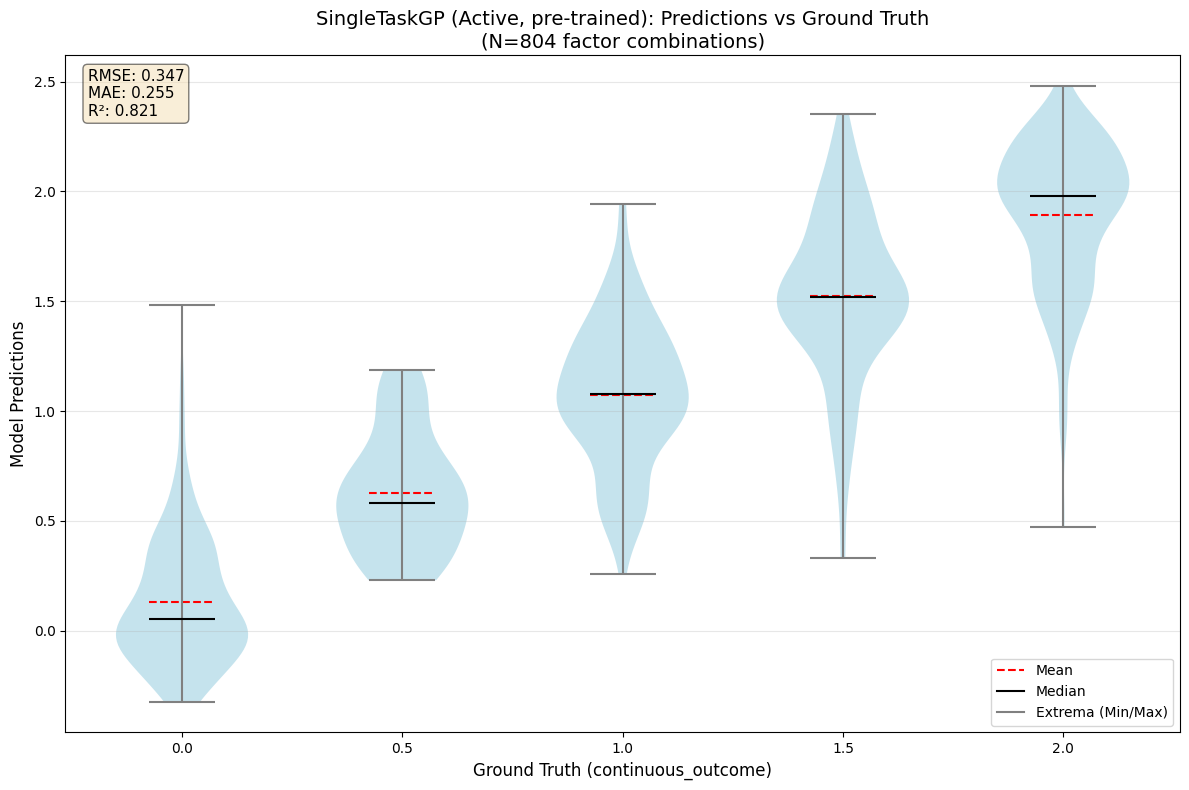

In [43]:
# Run violin plot analysis: Active model predictions vs ground truth
print("\n" + "="*60)
print("ACTIVE MODEL ANALYSIS")
print("="*60)
active_violin_results = plot_predictions_vs_ground_truth(
    active_model, 
    bf_data, 
    model_name=f"{active_model_name} (Active, pre-trained)"
)

Found 804 matching factor combinations out of 1089 total design points.


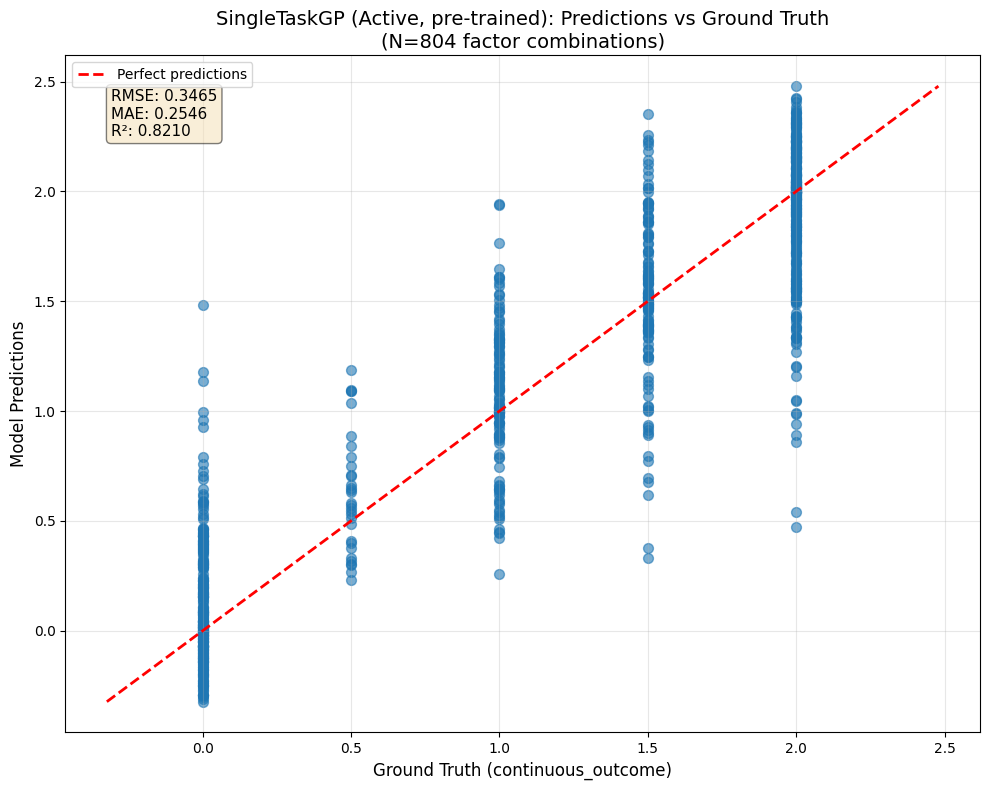

In [44]:
active_scatter_results = plot_predictions_vs_ground_truth_scatter(
    active_model, 
    bf_data, 
    model_name=f"{active_model_name} (Active, pre-trained)"
)


IID MODEL ANALYSIS
Found 804 matching factor combinations out of 1089 total design points.
Unique ground truth values: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0)]


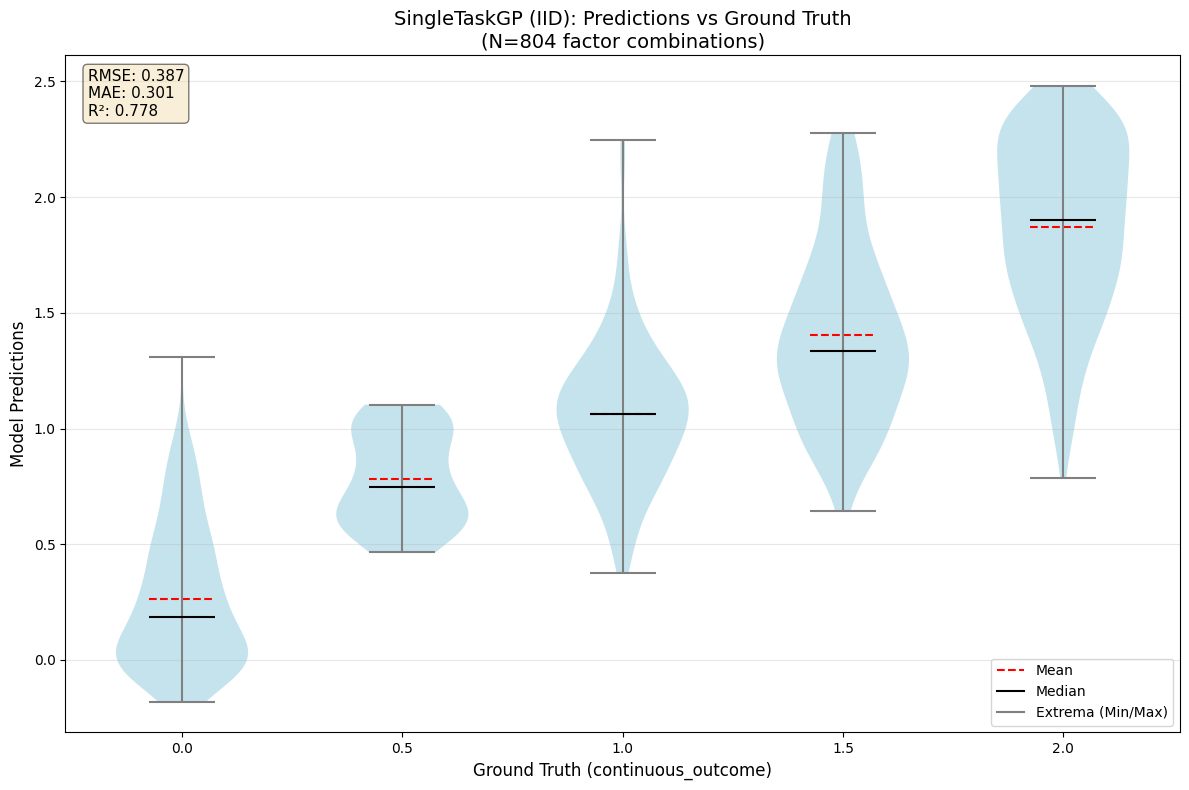

In [18]:
# Run violin plot analysis: IID model predictions vs ground truth
print("\n" + "="*60)
print("IID MODEL ANALYSIS")
print("="*60)

# If IID model not loaded, train one from IID data
if iid_model is None:
    print("Training IID model from IID results...")
    X_iid = torch.tensor(iid_data[FACTOR_COLUMNS].values, **tkwargs)
    y_iid = torch.tensor(iid_data['continuous_outcome'].values, **tkwargs).unsqueeze(-1)
    iid_model = fit_surrogate_model(X_iid, y_iid, BOUNDS, model_name=iid_model_name)
    print("IID model trained successfully.")

iid_results = plot_predictions_vs_ground_truth(
    iid_model,
    bf_data,
    model_name=f"{iid_model_name} (IID)"
)

Found 804 matching factor combinations out of 1089 total design points.


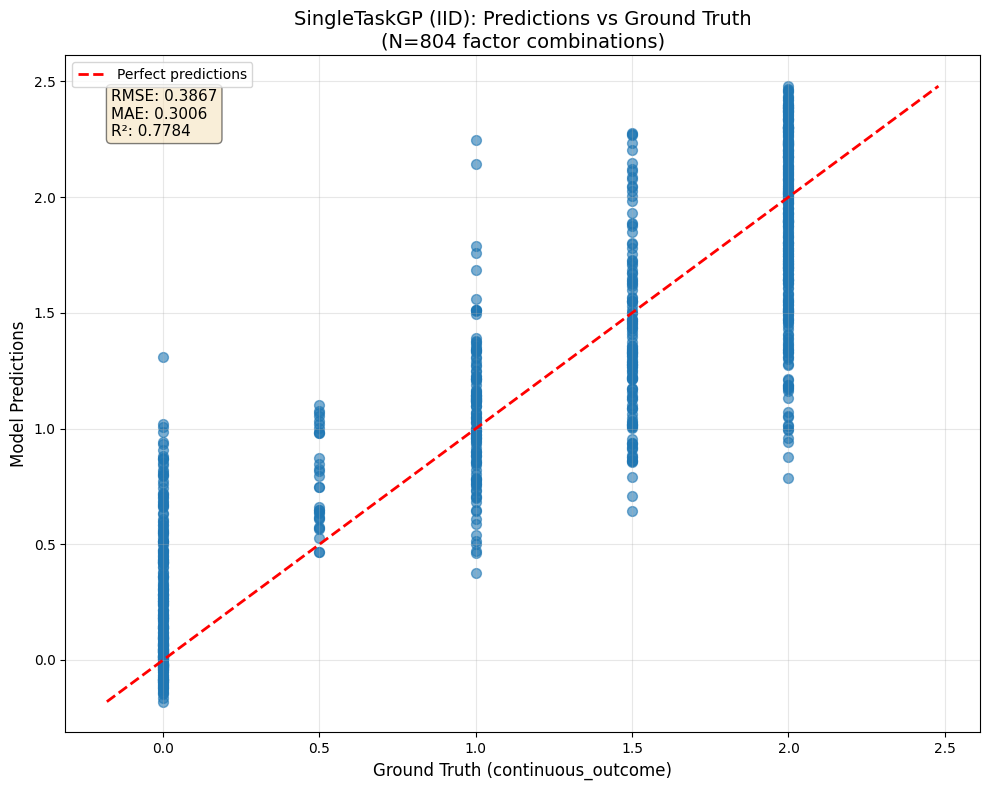

In [19]:
iid_scatter_results = plot_predictions_vs_ground_truth_scatter(
    iid_model, 
    bf_data, 
    model_name=f"{iid_model_name} (IID)"
)

In [20]:
# 2. Cross-validation: m repetitions of n%/(100-n)% train-test splits

def cross_validate_model(bf_data, model_name, m=10, train_split=0.8, random_state=None):
    """
    Performs m-fold cross-validation with n% train / (100-n)% test splits.
    
    Args:
        bf_data: DataFrame with ground truth data (must contain FACTOR_COLUMNS and 'continuous_outcome')
        model_name: Name of the model to use (e.g., 'SingleTaskGP', 'FullyBayesianSingleTaskGP')
        m: Number of repetitions/folds
        train_split: Fraction of data to use for training (e.g., 0.8 for 80% train, 20% test)
        random_state: Random seed for reproducibility (None for different splits each time)
    
    Returns:
        Dictionary with metrics for each fold and summary statistics
    """
    results = {
        'fold': [],
        'train_size': [],
        'test_size': [],
        'train_rmse': [],
        'test_rmse': [],
        'test_mae': [],
        'test_r2': []
    }
    
    # Prepare data
    X_all = torch.tensor(bf_data[FACTOR_COLUMNS].values, **tkwargs)
    y_all = torch.tensor(bf_data['continuous_outcome'].values, **tkwargs).unsqueeze(-1)
    
    print(f"Cross-validation: {m} repetitions, {train_split*100:.1f}% train / {(1-train_split)*100:.1f}% test")
    print(f"Total data points: {len(bf_data)}")
    print("-" * 60)
    
    for fold in range(m):
        # Create train-test split
        if random_state is not None:
            rs = random_state + fold
        else:
            rs = None
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_all.numpy(), y_all.numpy().flatten(),
            train_size=train_split,
            random_state=rs,
            shuffle=True
        )
        
        # Convert back to tensors
        X_train = torch.tensor(X_train, **tkwargs)
        y_train = torch.tensor(y_train, **tkwargs).unsqueeze(-1)
        X_test = torch.tensor(X_test, **tkwargs)
        y_test = torch.tensor(y_test, **tkwargs).unsqueeze(-1)
        
        # Fit model
        train_X = X_train
        train_Y = y_train
        
        try:
            fitted_model = fit_surrogate_model(train_X, train_Y, BOUNDS, model_name=model_name)
            
            # Evaluate on train set
            train_rmse = calculate_rmse(fitted_model, train_X, train_Y)
            
            # Evaluate on test set
            test_rmse = calculate_rmse(fitted_model, X_test, y_test)
            
            # Calculate additional metrics on test set
            with torch.no_grad():
                posterior = fitted_model.posterior(X_test)
                pred_mean = posterior.mean.squeeze(-1)
                if pred_mean.ndim == 2:
                    pred_mean = pred_mean.mean(dim=0)
                y_pred = pred_mean.cpu().numpy()
                y_true = y_test.cpu().numpy().flatten()
            
            test_mae = np.mean(np.abs(y_true - y_pred))
            test_r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
            
            # Store results
            results['fold'].append(fold + 1)
            results['train_size'].append(len(X_train))
            results['test_size'].append(len(X_test))
            results['train_rmse'].append(train_rmse)
            results['test_rmse'].append(test_rmse)
            results['test_mae'].append(test_mae)
            results['test_r2'].append(test_r2)
            
            print(f"Fold {fold+1}/{m}: Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f}, Test R²={test_r2:.4f}")
            
        except Exception as e:
            print(f"Fold {fold+1}/{m}: Error - {e}")
            continue
    
    # Convert to DataFrame for easier analysis
    results_df = pd.DataFrame(results)
    
    # Print summary statistics
    print("\n" + "=" * 60)
    print("Cross-Validation Summary Statistics:")
    print("=" * 60)
    print(f"Train RMSE: {results_df['train_rmse'].mean():.4f} ± {results_df['train_rmse'].std():.4f}")
    print(f"Test RMSE:  {results_df['test_rmse'].mean():.4f} ± {results_df['test_rmse'].std():.4f}")
    print(f"Test MAE:   {results_df['test_mae'].mean():.4f} ± {results_df['test_mae'].std():.4f}")
    print(f"Test R²:    {results_df['test_r2'].mean():.4f} ± {results_df['test_r2'].std():.4f}")
    
    return results_df

# Run cross-validation analysis
# Note: This trains new models on each fold, so specify the model_name you want to evaluate
cv_results = cross_validate_model(
    bf_data, 
    model_name='SingleTaskGP',  # Change to 'FullyBayesianSingleTaskGP', 'SaasFullyBayesianSingleTaskGP', etc.
    m=10,                        # Number of repetitions
    train_split=0.2,             # n% train, (100-n)% test
    random_state=42              # For reproducibility
)

Cross-validation: 10 repetitions, 20.0% train / 80.0% test
Total data points: 804
------------------------------------------------------------
Fold 1/10: Train RMSE=0.1506, Test RMSE=0.3086, Test R²=0.8552
Fold 2/10: Train RMSE=0.1689, Test RMSE=0.3160, Test R²=0.8530
Fold 3/10: Train RMSE=0.2209, Test RMSE=0.3272, Test R²=0.8432
Fold 4/10: Train RMSE=0.1370, Test RMSE=0.3069, Test R²=0.8567
Fold 5/10: Train RMSE=0.1538, Test RMSE=0.3327, Test R²=0.8370
Fold 6/10: Train RMSE=0.1449, Test RMSE=0.3145, Test R²=0.8514
Fold 7/10: Train RMSE=0.1872, Test RMSE=0.3367, Test R²=0.8324
Fold 8/10: Train RMSE=0.1274, Test RMSE=0.3236, Test R²=0.8437
Fold 9/10: Train RMSE=0.1608, Test RMSE=0.3752, Test R²=0.7895
Fold 10/10: Train RMSE=0.1849, Test RMSE=0.3305, Test R²=0.8394

Cross-Validation Summary Statistics:
Train RMSE: 0.1636 ± 0.0278
Test RMSE:  0.3272 ± 0.0197
Test MAE:   0.2332 ± 0.0122
Test R²:    0.8401 ± 0.0196


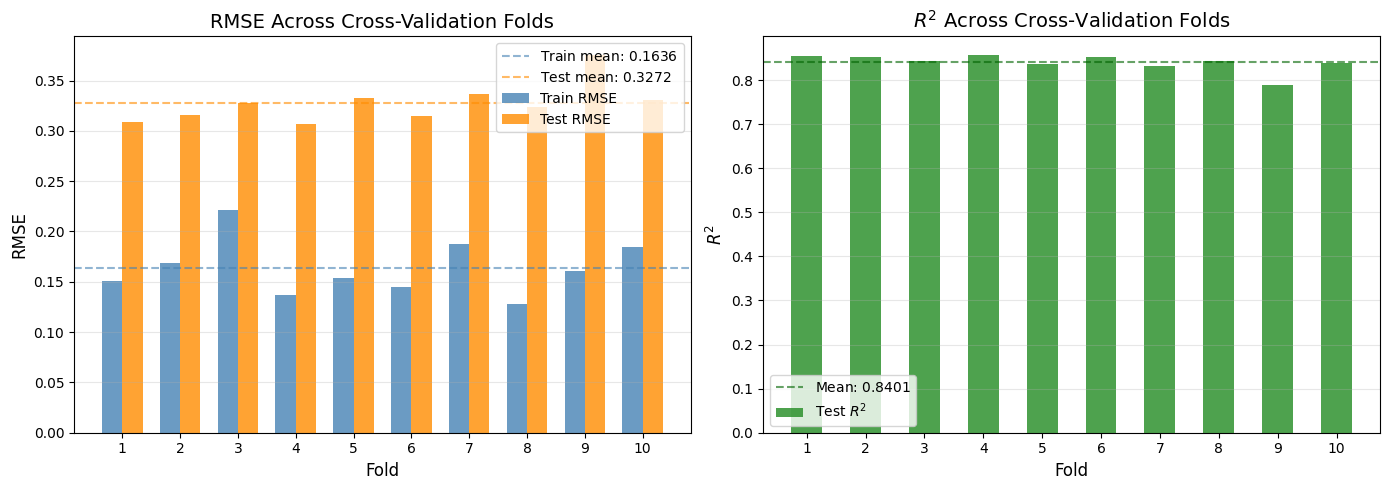

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cv_results(cv_results):
    """
    Creates visualizations of cross-validation results using bar plots.
    
    Args:
        cv_results: DataFrame returned by cross_validate_model()
    """
    # Use subplots instead of figure() as per guidelines
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    folds = cv_results['fold']
    x = np.arange(len(folds))  # The label locations
    width = 0.35  # The width of the bars
    
    # Plot 1: RMSE across folds (Grouped Bar Chart)
    ax1 = axes[0]
    ax1.bar(x - width/2, cv_results['train_rmse'], width, label='Train RMSE', color='steelblue', alpha=0.8)
    ax1.bar(x + width/2, cv_results['test_rmse'], width, label='Test RMSE', color='darkorange', alpha=0.8)
    
    # Reference mean lines
    train_mean = cv_results['train_rmse'].mean()
    test_mean = cv_results['test_rmse'].mean()
    ax1.axhline(train_mean, color='steelblue', linestyle='--', alpha=0.6, label=f'Train mean: ${train_mean:.4f}$')
    ax1.axhline(test_mean, color='darkorange', linestyle='--', alpha=0.6, label=f'Test mean: ${test_mean:.4f}$')
    
    ax1.set_xlabel('Fold', fontsize=12)
    ax1.set_ylabel('RMSE', fontsize=12)
    ax1.set_title('RMSE Across Cross-Validation Folds', fontsize=14)
    ax1.set_xticks(x)
    ax1.set_xticklabels(folds)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Plot 2: R² across folds (Single Bar Chart)
    ax2 = axes[1]
    ax2.bar(x, cv_results['test_r2'], width * 1.5, color='forestgreen', label='Test $R^2$', alpha=0.8)
    
    # Reference mean line
    r2_mean = cv_results['test_r2'].mean()
    ax2.axhline(r2_mean, color='darkgreen', linestyle='--', alpha=0.6, label=f'Mean: ${r2_mean:.4f}$')
    
    ax2.set_xlabel('Fold', fontsize=12)
    ax2.set_ylabel('$R^2$', fontsize=12)
    ax2.set_title('$R^2$ Across Cross-Validation Folds', fontsize=14)
    ax2.set_xticks(x)
    ax2.set_xticklabels(folds)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualize cross-validation results
plot_cv_results(cv_results)

## Data Curation experiment

In [38]:
test_data = pd.read_csv('./results/uprightcup_bruteforce/results.csv')
upright_topleft_th2_outcome = test_data[(test_data['x'].round(1)<=0.5)&(test_data['y'].round(1)>=0.5)&(test_data['table_height']==2.0)]['continuous_outcome'].mean()
print(upright_topleft_th2_outcome)

0.5972222222222222


Table saved as ./visualizations/robo_eval/data_curation/collection_strategy_comparison.png


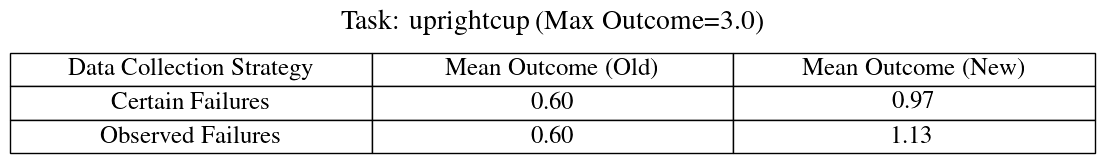

In [40]:
certain_failures_results = pd.read_csv('./results/uprightcup_certain_failures_bruteforce/results.csv')
observed_failures_results = pd.read_csv('./results/uprightcup_observed_failures_bruteforce/results.csv') 

def summarize_and_save_results(certain_df, observed_df, filename="failure_summary.png"):
    summary_data = []
    for df, label in zip([certain_df, observed_df], ['Certain Failures', 'Observed Failures']):
        mean_outcome = df['continuous_outcome'].mean()
        std_outcome = df['continuous_outcome'].std()
        summary_data.append({
            'Data Collection Strategy': label,
            'Mean Outcome (Old)': f"{upright_topleft_th2_outcome:.2f}",
            f'Mean Outcome (New)': round(mean_outcome, 2),
            # 'Std Dev': round(std_outcome, 2),
        })
    
    summary_df = pd.DataFrame(summary_data)

    # --- Saving Logic ---
    fig, ax = plt.subplots(figsize=(10, 0.5)) # Adjust size as needed
    ax.axis('off')
    # ax.title(f'uprightcup (Max Outcome:{MAX_OUTCOME["uprightcup"]})', fontsize=14)
    
    # Create the table
    tbl = ax.table(cellText=summary_df.values, 
                   colLabels=summary_df.columns, 
                   cellLoc='center', 
                   loc='center')
    
    # Styling for a clean, colorless look
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(18)
    tbl.scale(1.4, 2)

    # add title
    ax.set_title(f'Task: uprightcup (Max Outcome={MAX_OUTCOME["uprightcup"]})', pad=40, fontsize=20)

    # Loop through the cells to bold the header row
    for (row, col), cell in tbl.get_celld().items():
        if row == 0: # This targets the header row
            cell.set_text_props(weight='bold')
    
    # Save the file
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    print(f"Table saved as {filename}")
    
    return summary_df

# Run and save
summary_table = summarize_and_save_results(certain_failures_results, observed_failures_results, filename="./visualizations/robo_eval/data_curation/collection_strategy_comparison.png")

In [50]:
print(f"Certain Failures: {len(certain_failures_results)} rows")
print(f"Observed Failures: {len(observed_failures_results)} rows")

Certain Failures: 108 rows
Observed Failures: 108 rows


In [ ]:
# Optional: Compare multiple models with cross-validation
# Uncomment to run comparisons:

# models_to_test = ['SingleTaskGP', 'MDN', 'DeepEnsemble']
# cv_comparison = {}

# for model_name in models_to_test:
#     print(f"\n{'='*60}")
#     print(f"Testing {model_name}")
#     print('='*60)
#     cv_comparison[model_name] = cross_validate_model(
#         bf_data, 
#         model_name=model_name,
#         m=10,
#         train_split=0.8,
#         random_state=42
#     )

# # Compare results
# print("\n" + "="*60)
# print("Model Comparison Summary")
# print("="*60)
# for model_name, results in cv_comparison.items():
#     print(f"\n{model_name}:")
#     print(f"  Test RMSE: {results['test_rmse'].mean():.4f} ± {results['test_rmse'].std():.4f}")
#     print(f"  Test R²:   {results['test_r2'].mean():.4f} ± {results['test_r2'].std():.4f}")